In [2]:
from forecast import AnalisadorSerieTemporalCompleto
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

SÉRIE TEMPORAL: IPG2211A2N
Período: 2020-11-01 00:00:00 até 2025-08-01 00:00:00
Frequência: MS
Total de observações: 58
Treino: 46 | Teste: 12


INICIANDO ANÁLISE COMPLETA DE SÉRIE TEMPORAL

1. ANÁLISE EXPLORATÓRIA DE DADOS

ESTATÍSTICAS DESCRITIVAS
--------------------------------------------------
Média...................................          105.63
Mediana.................................          104.27
Desvio Padrão...........................           10.92
Coef. Variação..........................           10.34
Mínimo..................................           87.61
Máximo..................................          131.92
Amplitude...............................           44.30
Q1 (25%)................................           96.19
Q3 (75%)................................          114.93
IQR.....................................           18.74
Assimetria..............................            0.24
Curtose.................................           -0.90

Variação Total

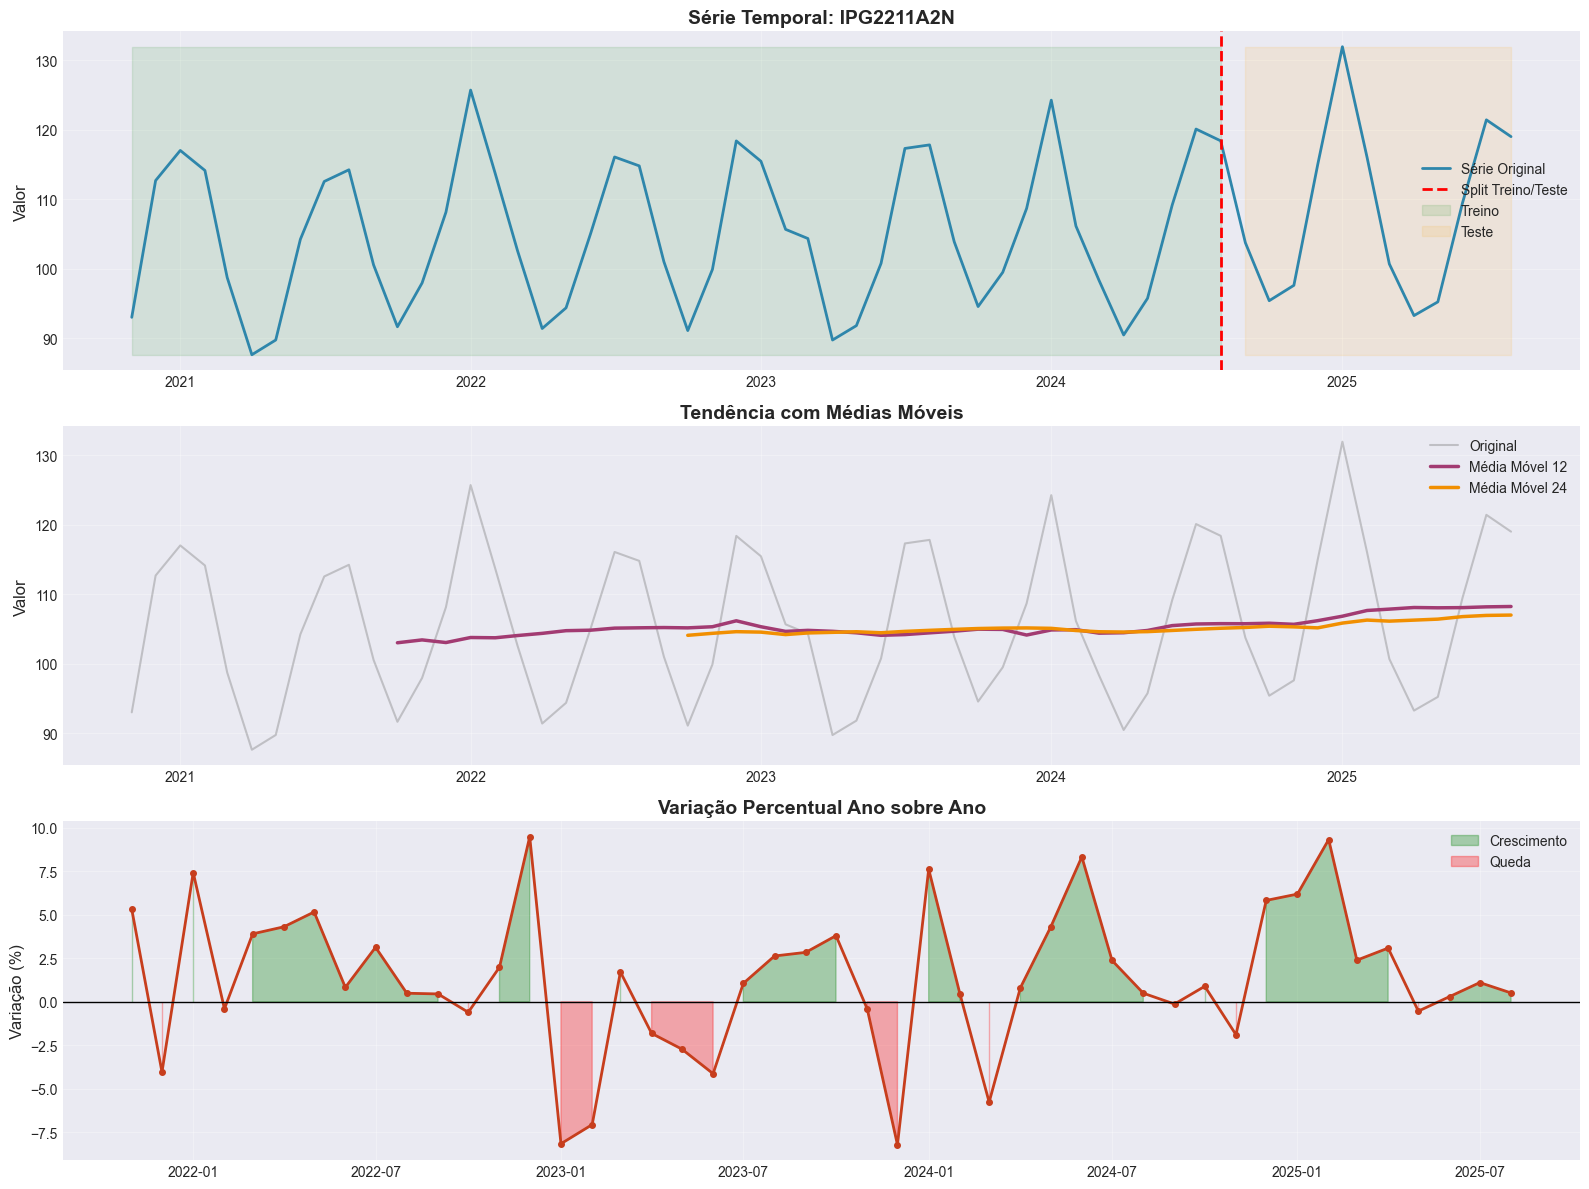

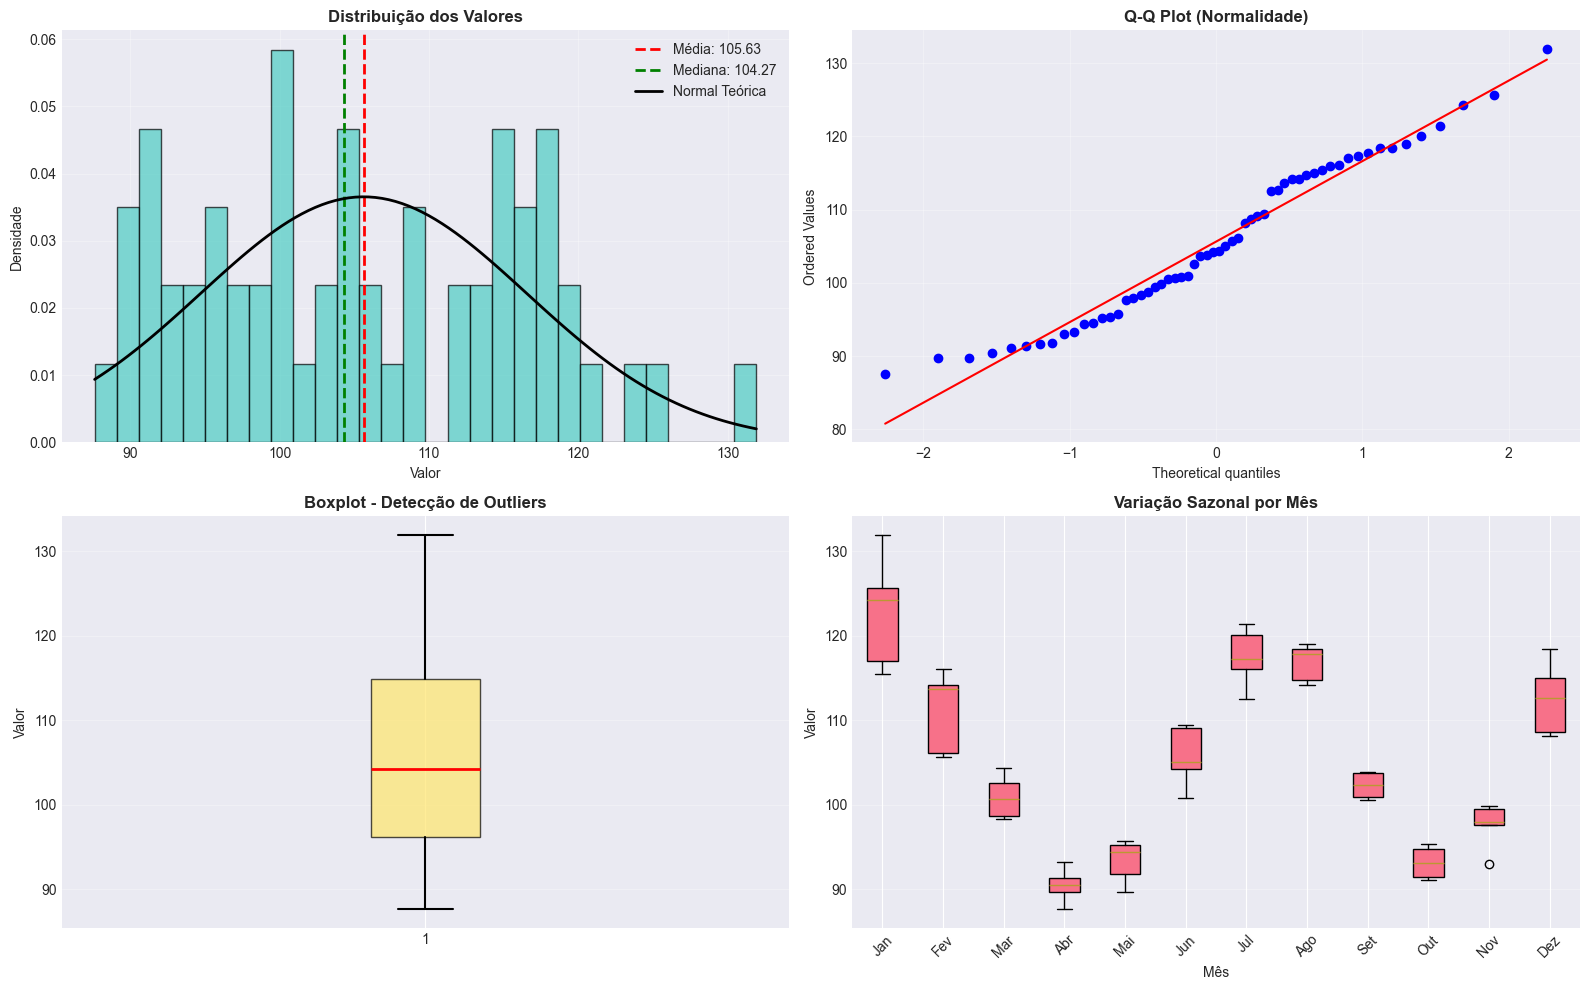

TESTE DE NORMALIDADE (Jarque-Bera)
Estatística: 2.5990
P-valor: 0.2727
Conclusão: Distribuição NORMAL (α=0.05)

DETECÇÃO DE OUTLIERS
Método IQR: 0 outliers (0.00%)
Método Z-Score (>3): 0 outliers (0.00%)



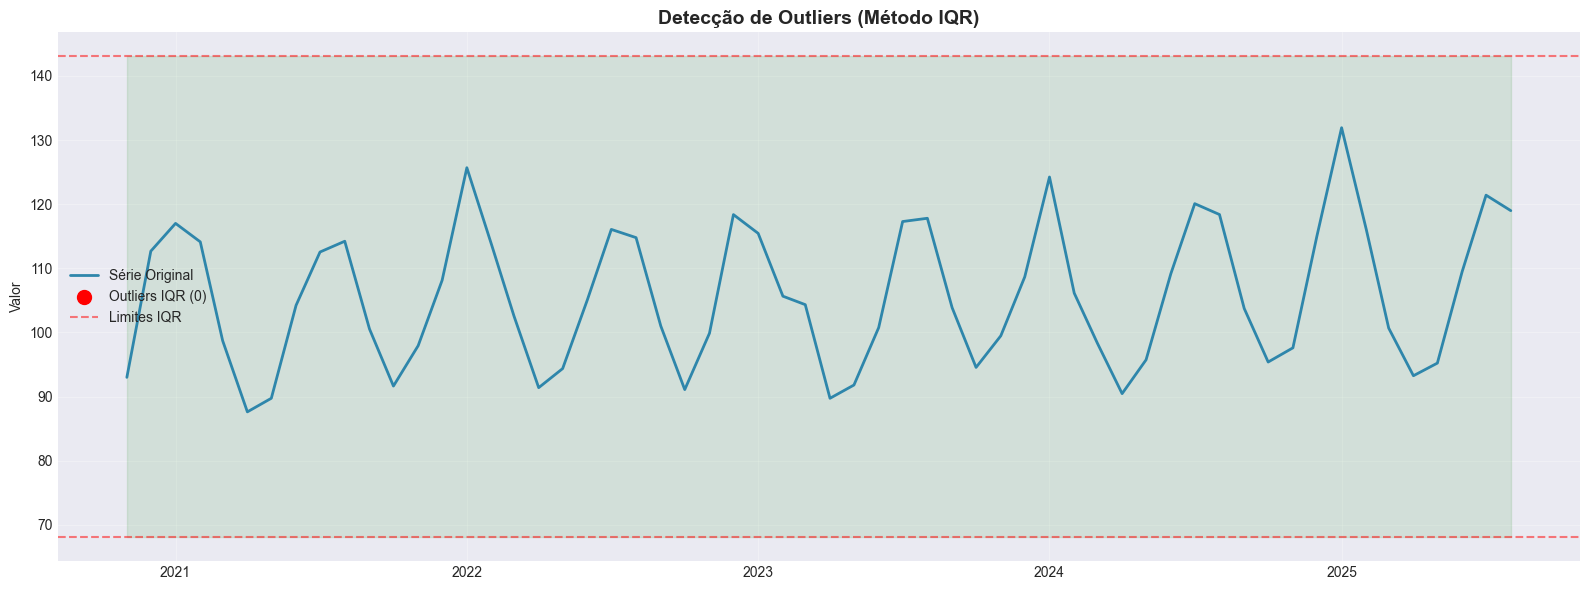


2. DECOMPOSIÇÃO SAZONAL



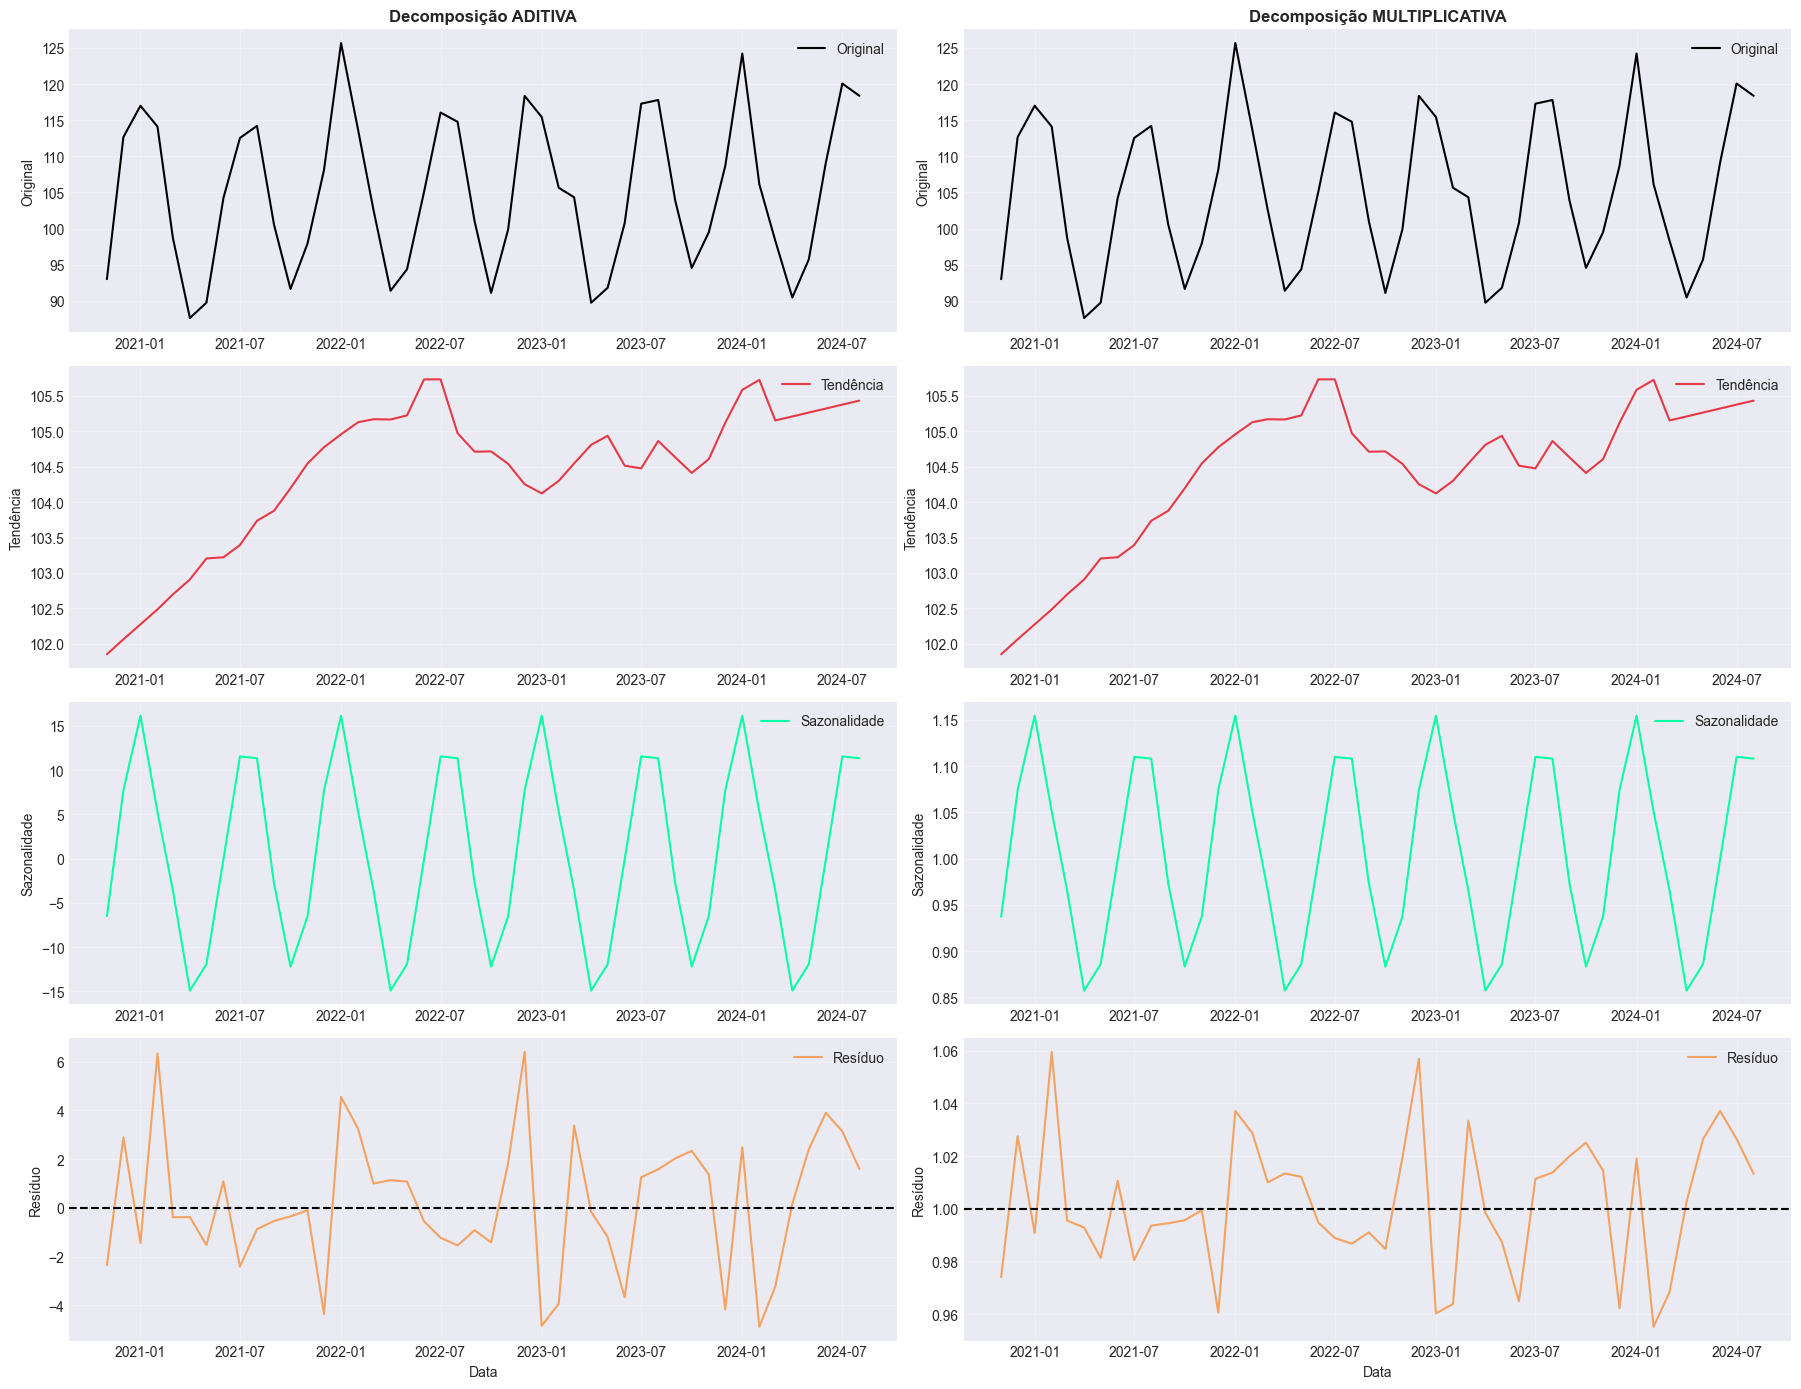

FORÇA DOS COMPONENTES (Aditivo)
Força da Sazonalidade: 0.9305
Força da Tendência: 0.1202



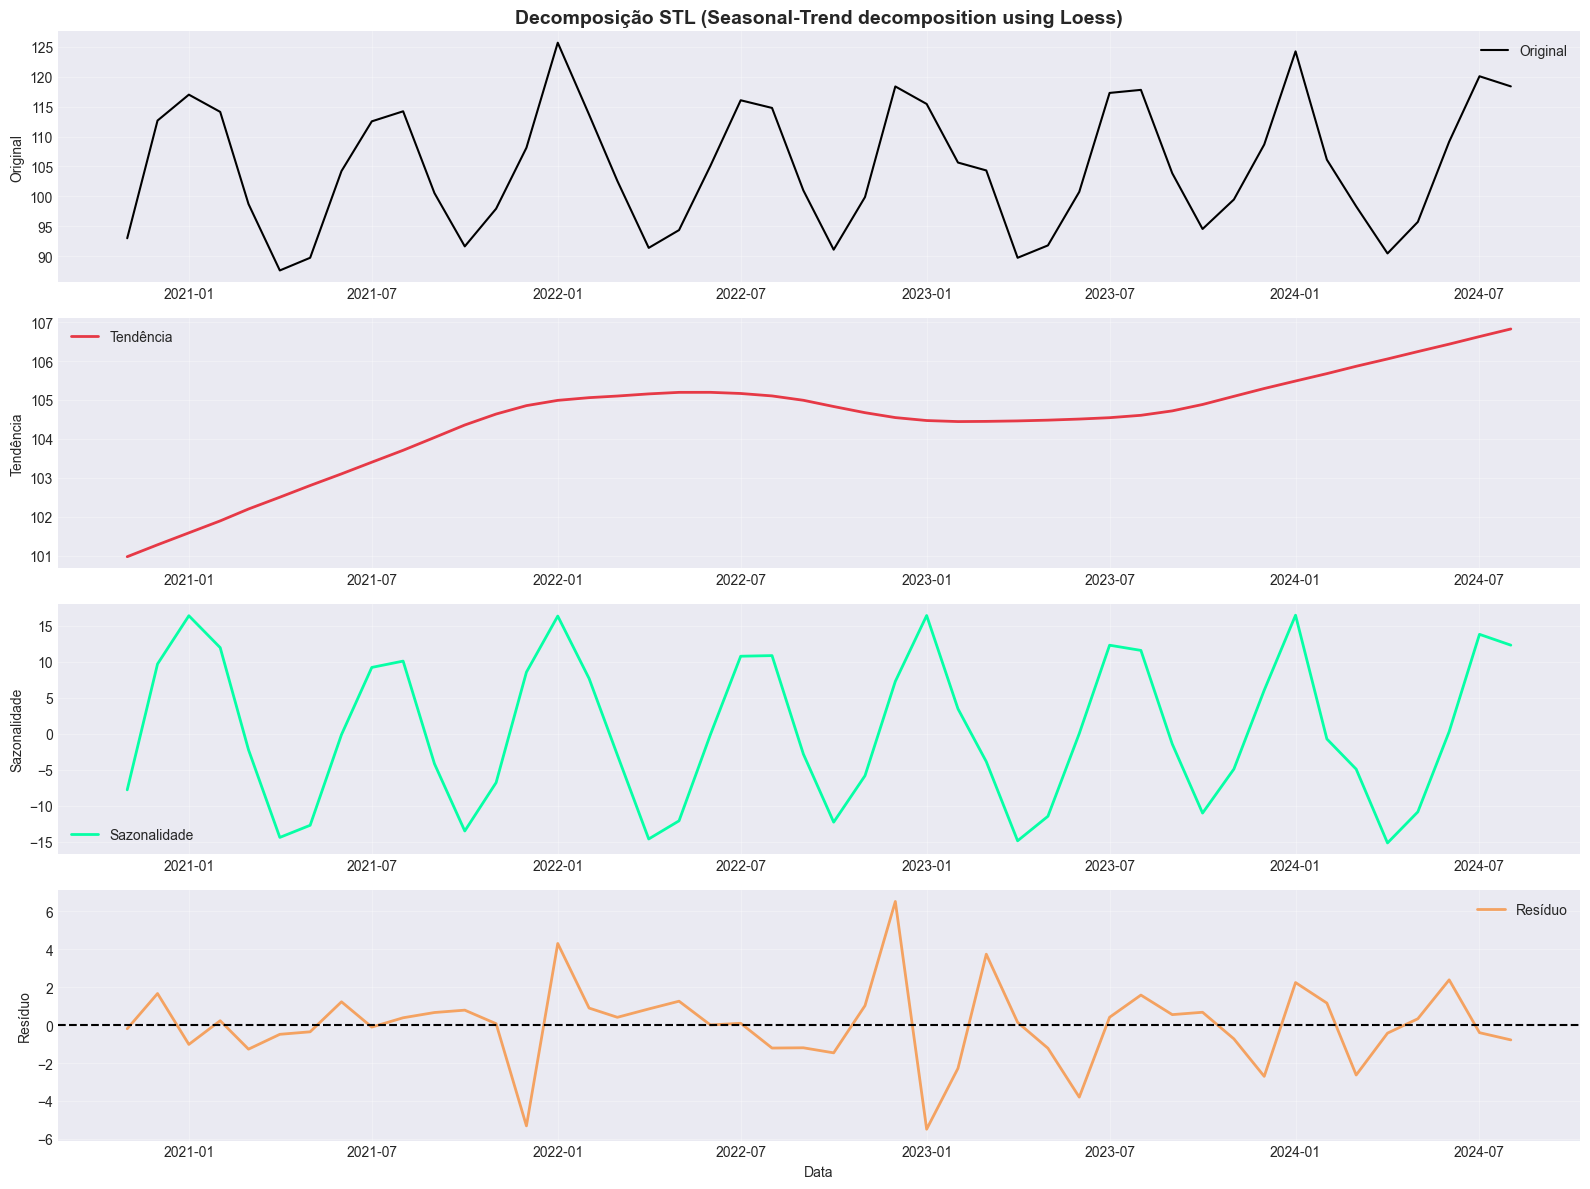


3. TESTES DE ESTACIONARIEDADE

TESTE ADF (Augmented Dickey-Fuller)
--------------------------------------------------
Estatística ADF: -4.753237
P-valor: 0.000067
Lags utilizados: 8
Número de observações: 37
Valores críticos:
  1%: -3.6209
  5%: -2.9435
  10%: -2.6104
Conclusão: Série é ESTACIONÁRIA (rejeita H0: raiz unitária)

TESTE KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
--------------------------------------------------
Estatística KPSS: 0.023493
P-valor: 0.100000
Lags utilizados: 2
Valores críticos:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Conclusão: Série é ESTACIONÁRIA (não rejeita H0: estacionária)

INTERPRETAÇÃO COMBINADA:
Série é ESTACIONÁRIA (ambos os testes concordam)



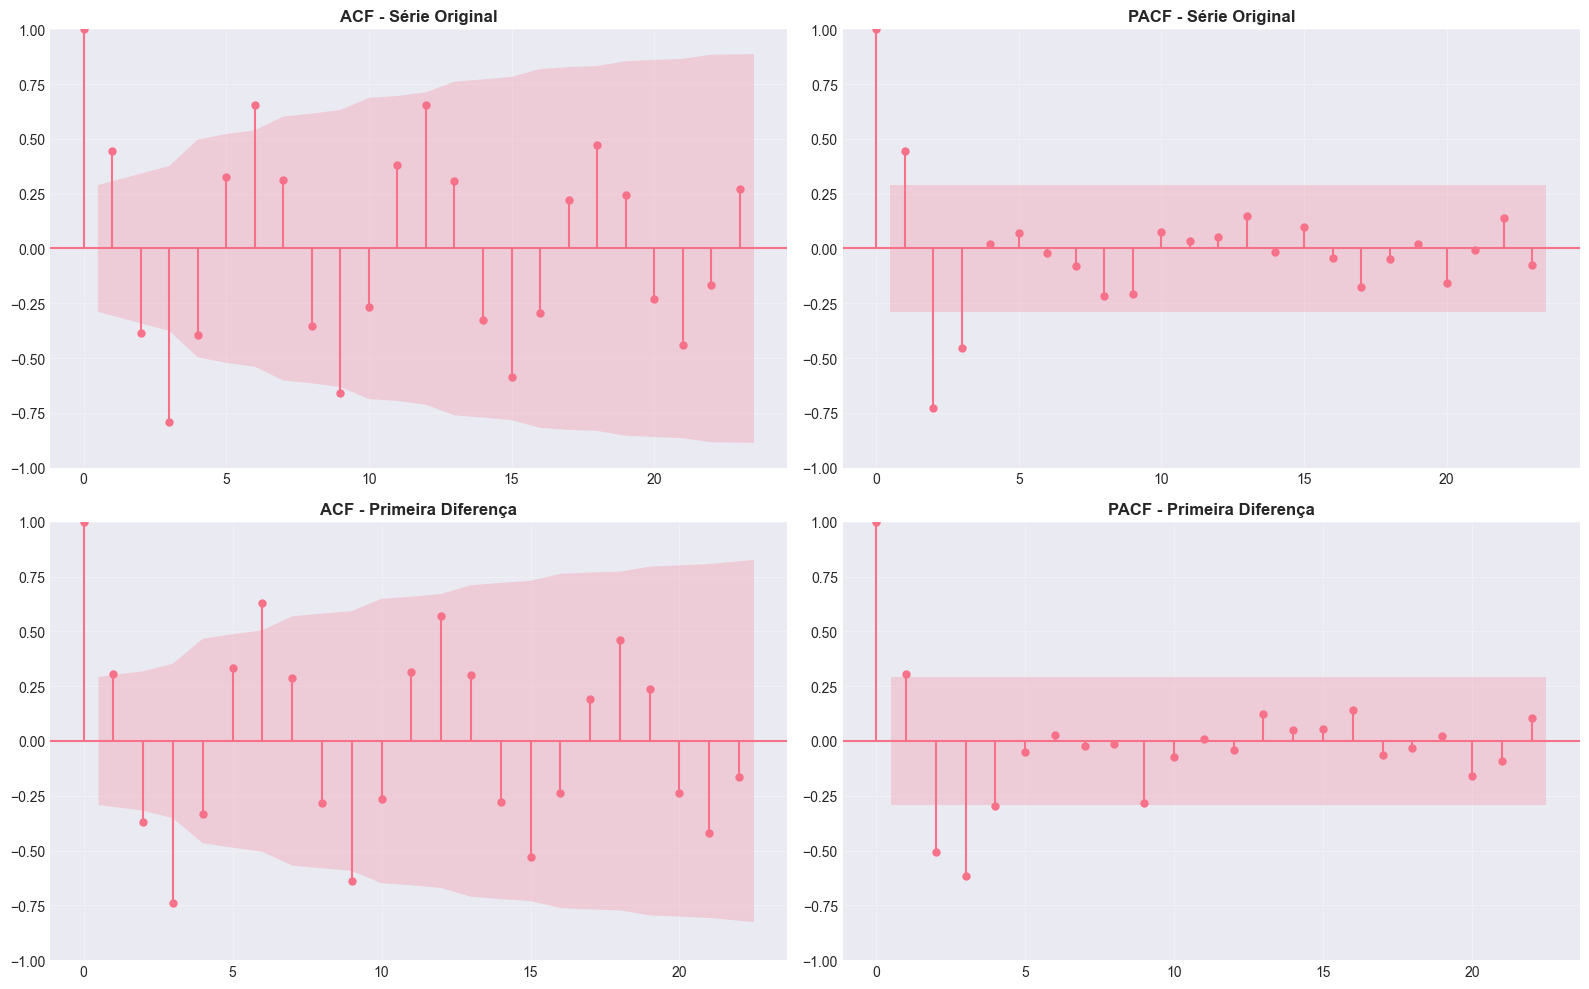


4. AJUSTE E COMPARAÇÃO DE MODELOS

RANDOM FOREST REGRESSOR
--------------------------------------------------
Random Forest treinado com sucesso
  Número de árvores: 200
  Features mais importantes:
    lag_3: 0.4530
    lag_12: 0.3992
    lag_9: 0.0354
    lag_6: 0.0240
    rolling_std_3: 0.0229


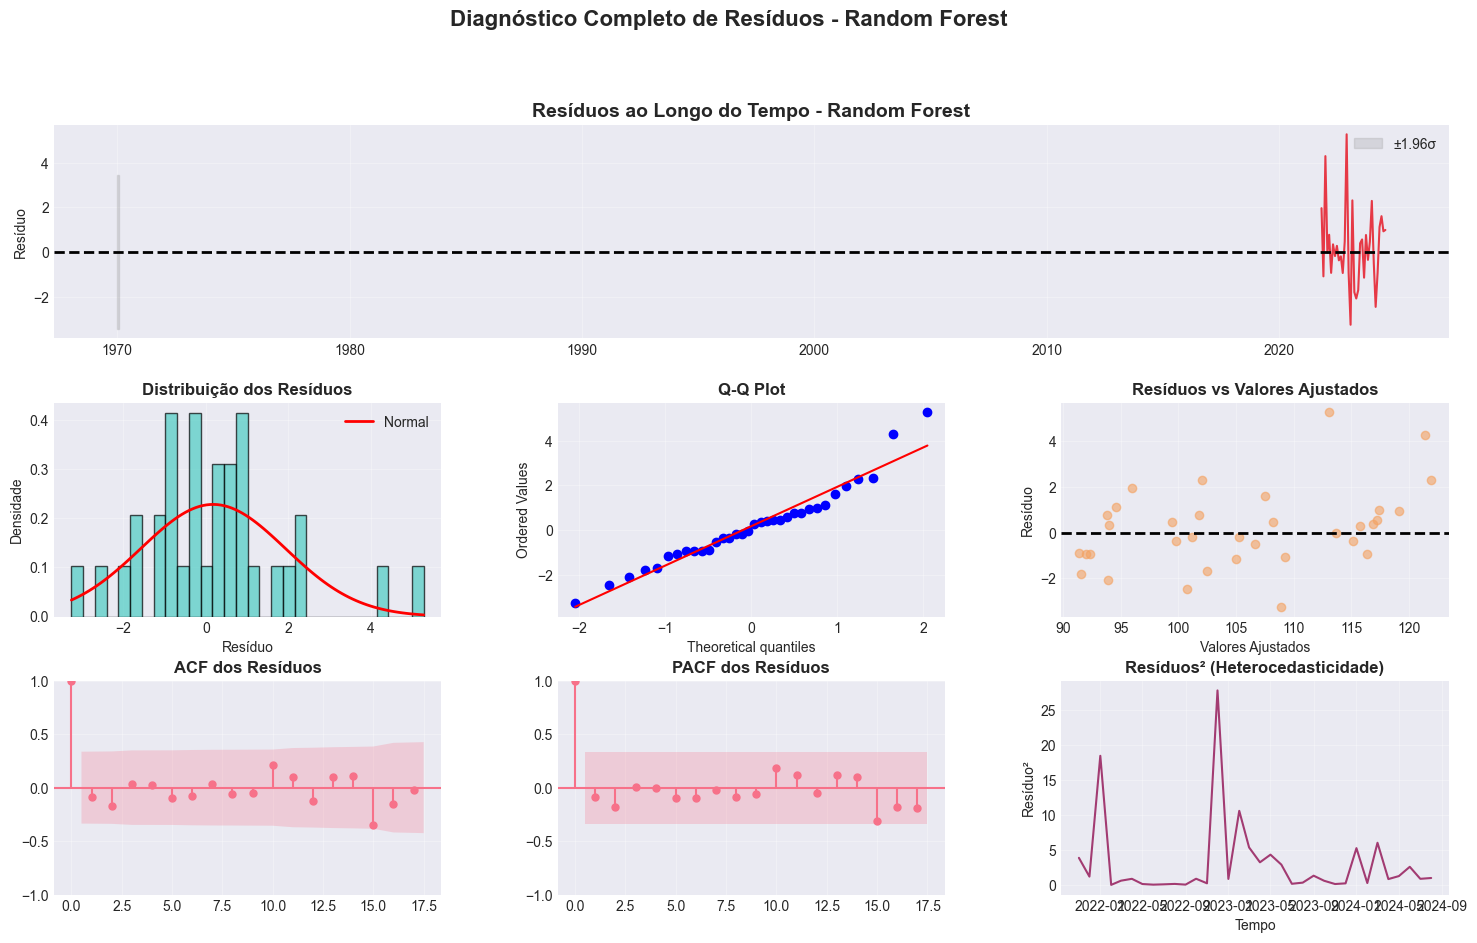


TESTES ESTATÍSTICOS DOS RESÍDUOS - Random Forest
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 5.6398 | P-valor: 0.0596
  Resíduos NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.4978
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: 0.176676 (deveria ser ~0)
  Desvio Padrão: 1.7509
  Assimetria: 0.8260
  Curtose: 1.6211
------------------------------------------------------------

Random Forest ajustado com sucesso

HOLT-WINTERS (SUAVIZAÇÃO EXPONENCIAL)
--------------------------------------------------
✓ Melhor configuração: HW_add_add
  AIC: 125.84
  BIC: 155.10


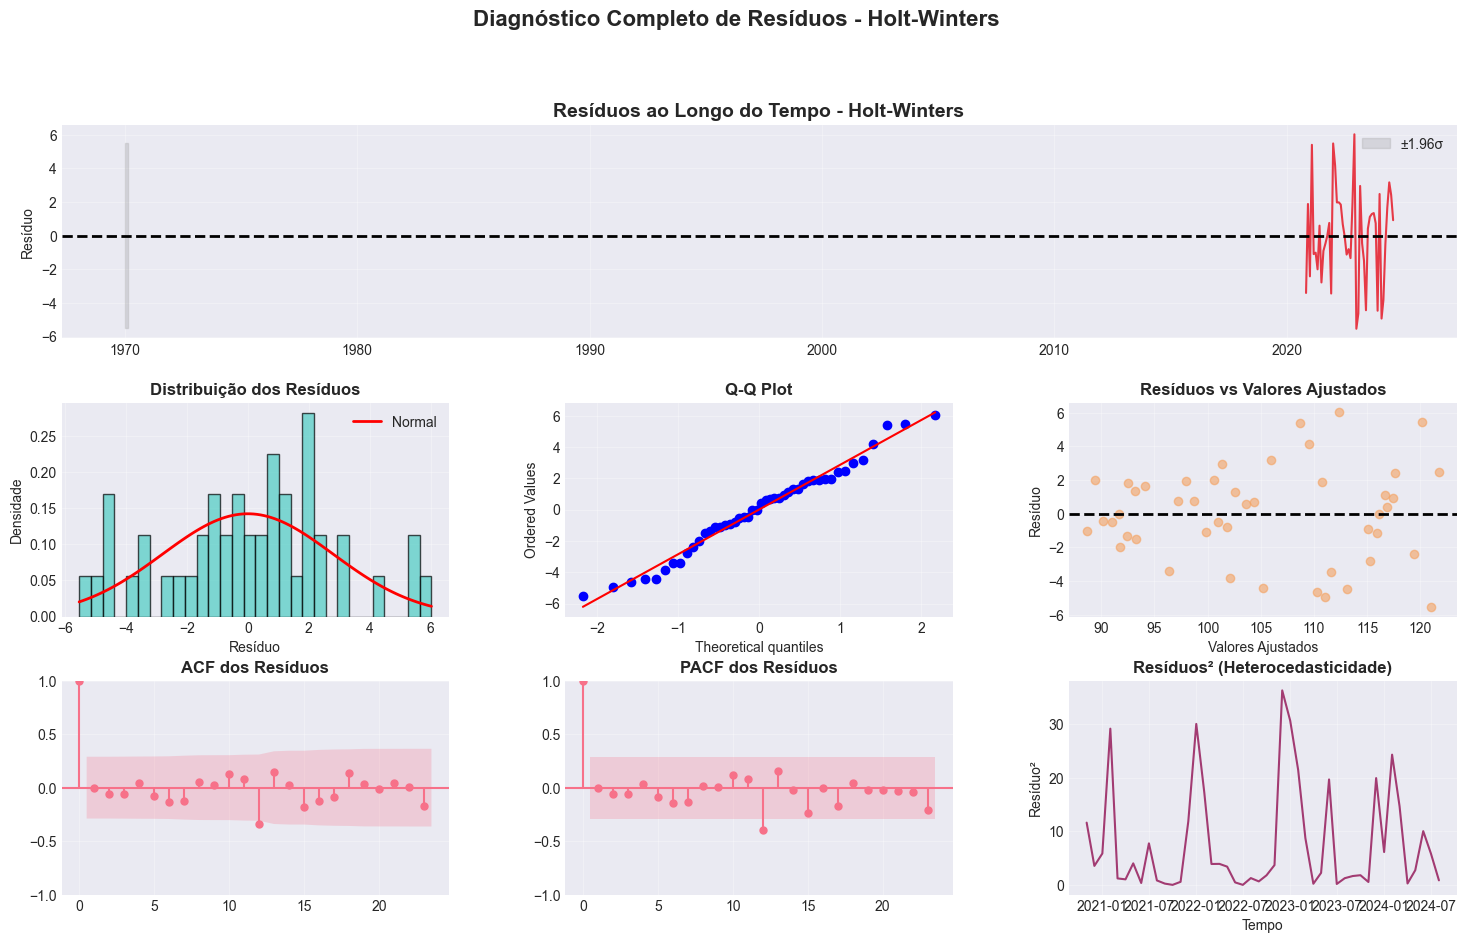


TESTES ESTATÍSTICOS DOS RESÍDUOS - Holt-Winters
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 0.2972 | P-valor: 0.8619
  Resíduos NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.9128
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: -0.000001 (deveria ser ~0)
  Desvio Padrão: 2.8039
  Assimetria: -0.0093
  Curtose: -0.2970
------------------------------------------------------------

✓ Holt-Winters ajustado com sucesso

SARIMA (AUTO-ARIMA)
--------------------------------------------------
Buscando melhor modelo SARIMA (pode levar alguns minutos)...
Melhor modelo: ARIMA(0, 0, 0) x (1, 1, 0, 12)[12]
  AIC: 196.05
  BIC: 200.63


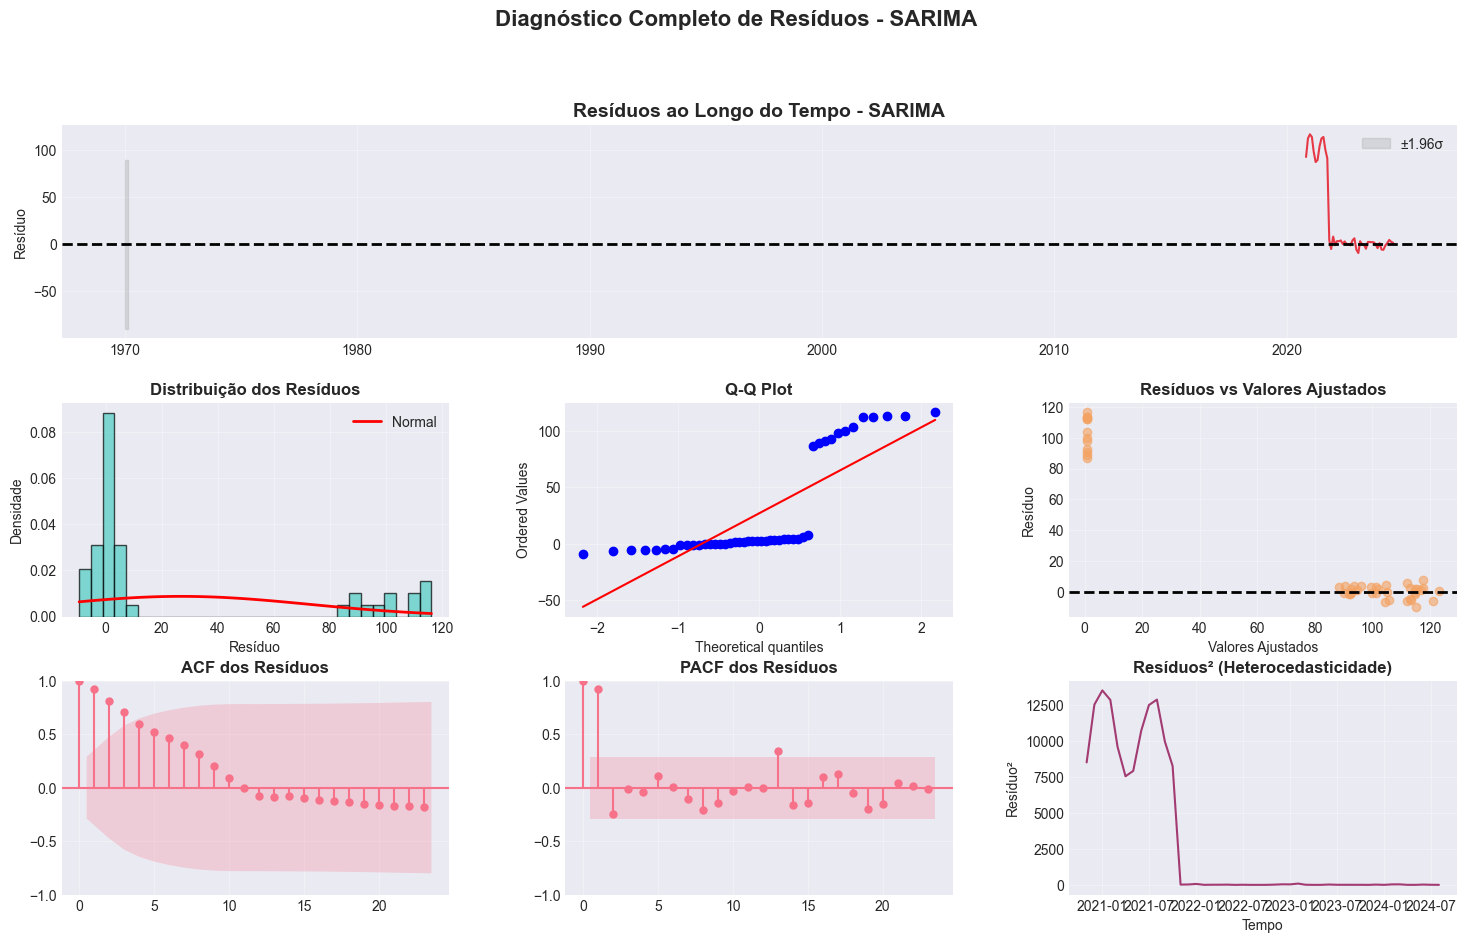

10:36:44 - cmdstanpy - INFO - Chain [1] start processing



TESTES ESTATÍSTICOS DOS RESÍDUOS - SARIMA
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 10.3910 | P-valor: 0.0055
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0000
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 26.936795 (deveria ser ~0)
  Desvio Padrão: 45.7178
  Assimetria: 1.1551
  Curtose: -0.5902
------------------------------------------------------------

SARIMA ajustado com sucesso

PROPHET
--------------------------------------------------


10:36:44 - cmdstanpy - INFO - Chain [1] done processing


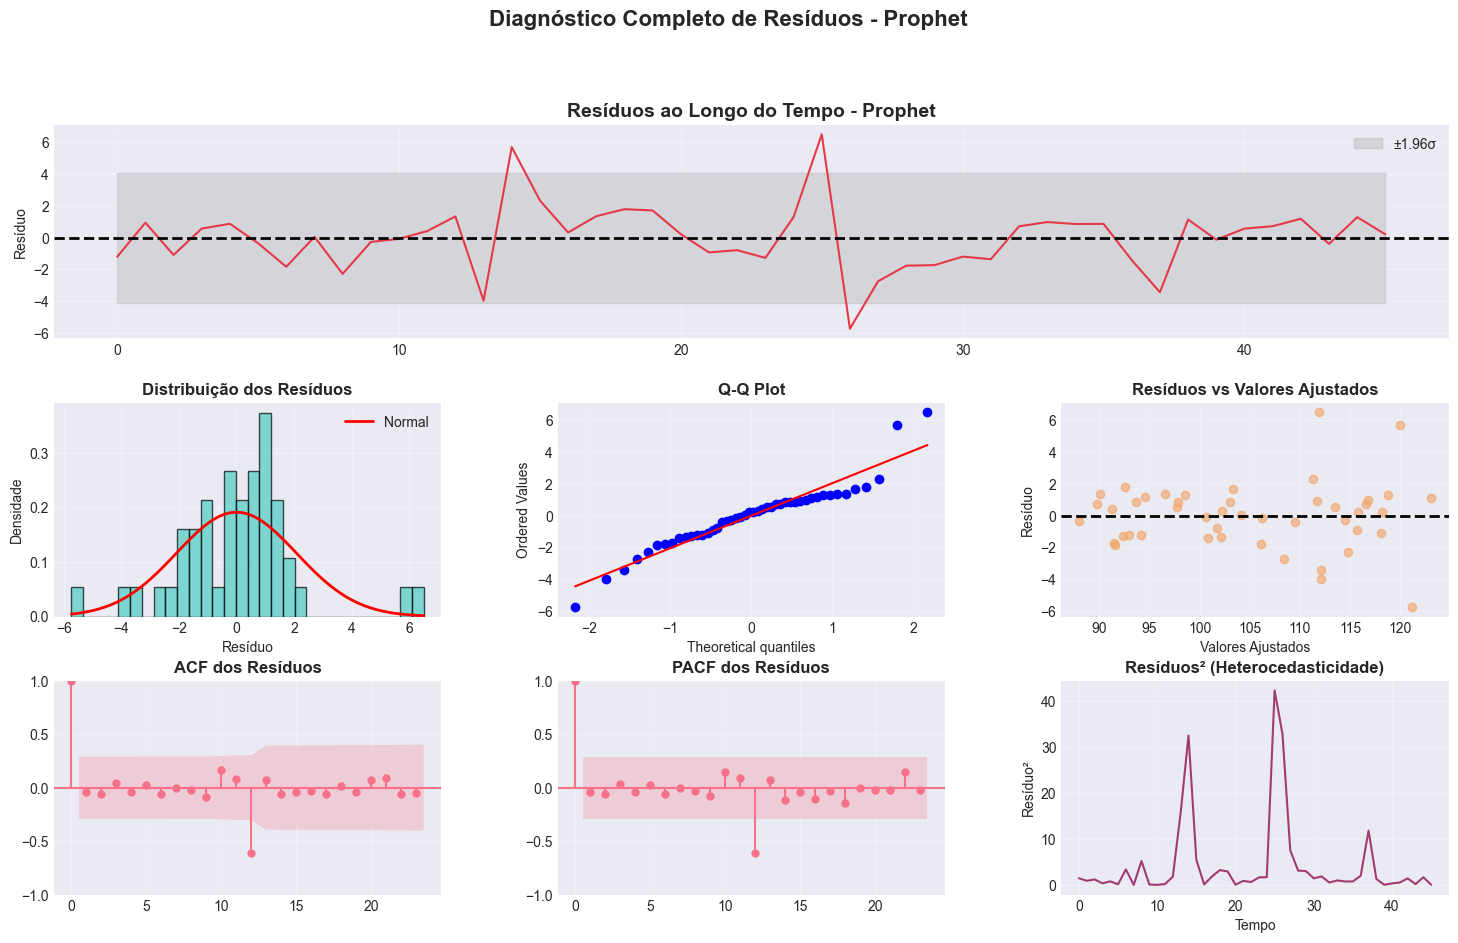


TESTES ESTATÍSTICOS DOS RESÍDUOS - Prophet
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 11.9725 | P-valor: 0.0025
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.7521
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: -0.000083 (deveria ser ~0)
  Desvio Padrão: 2.0893
  Assimetria: 0.3740
  Curtose: 2.8170
------------------------------------------------------------



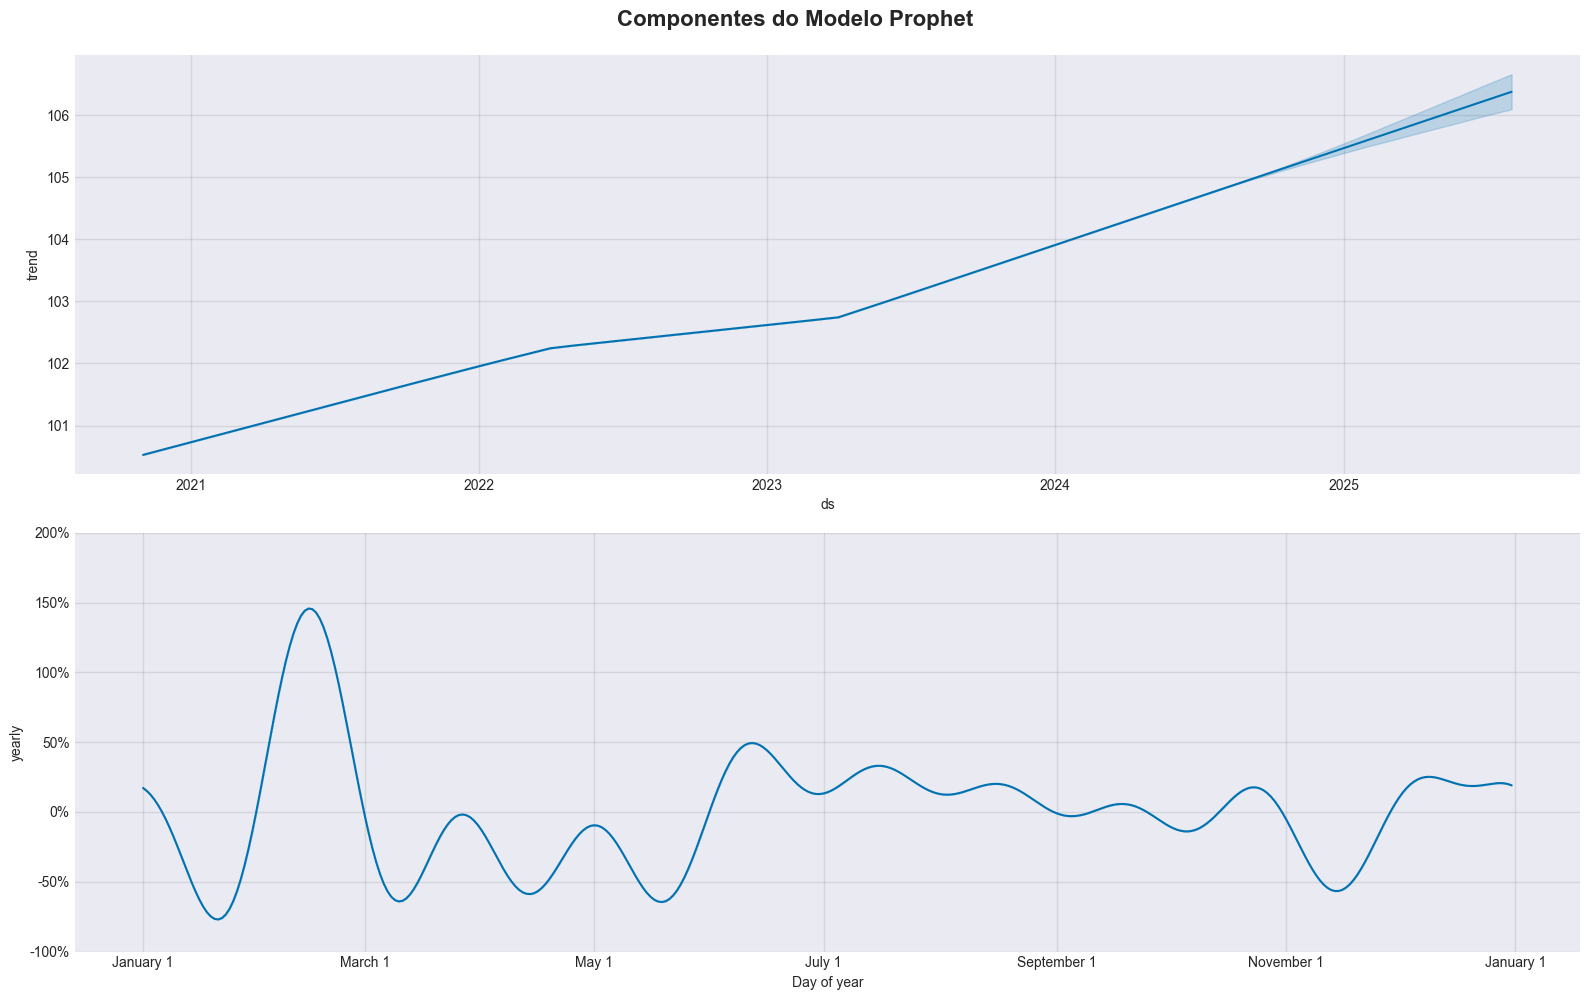

Prophet ajustado com sucesso


5. COMPARAÇÃO VISUAL DOS MODELOS



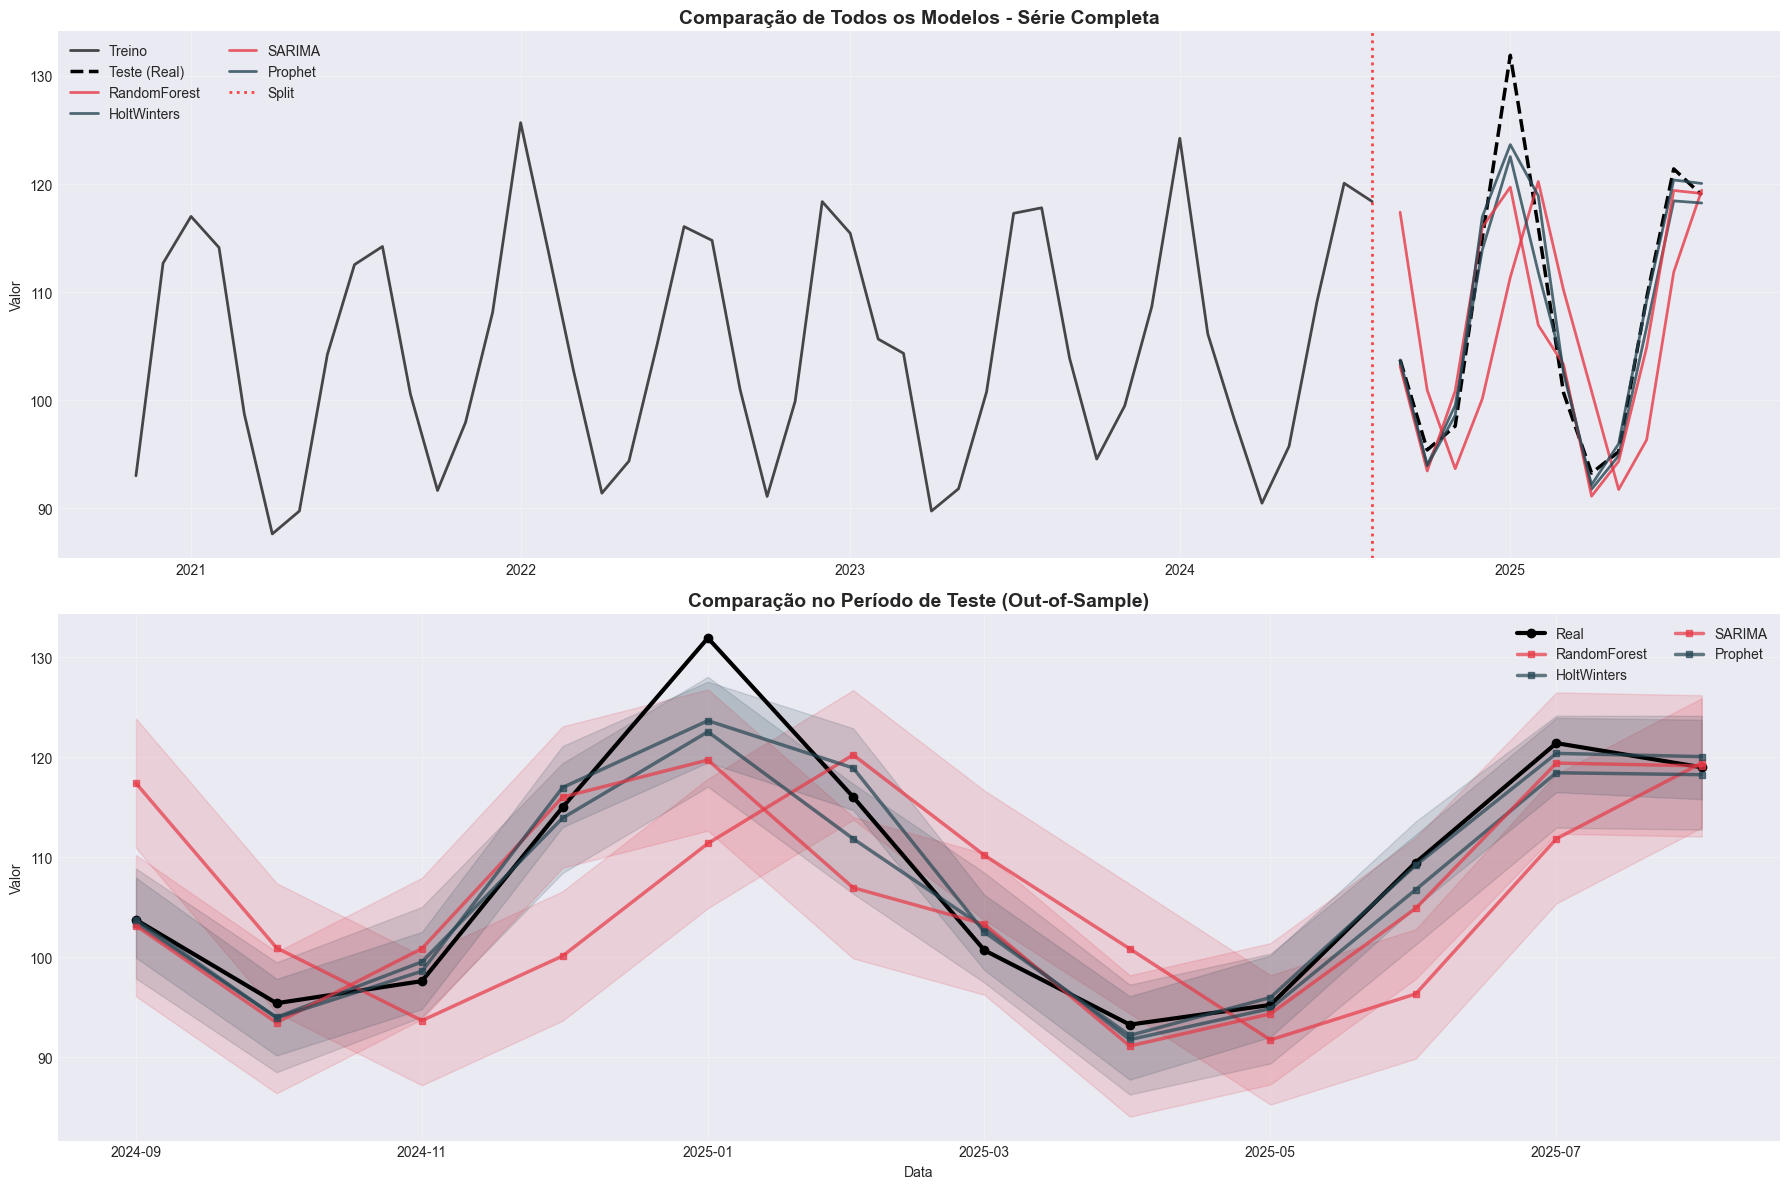


6. RANKING E MÉTRICAS DE PERFORMANCE

TABELA DE MÉTRICAS (ordenada por melhor performance)
                 MAE     RMSE    MAPE   SMAPE      R²  Rank_Médio
Prophet       1.8010   2.7557  1.5647  1.5773  0.9466         1.0
HoltWinters   2.4063   3.3733  2.1024  2.1338  0.9200         2.0
SARIMA        3.3708   4.8671  2.9731  3.0424  0.8335         3.0
RandomForest  8.8758  10.4826  8.0552  8.1941  0.2276         4.0

MELHOR MODELO: Prophet
   MAE: 1.8010
   RMSE: 2.7557
   MAPE: 1.56%
   R²: 0.9466


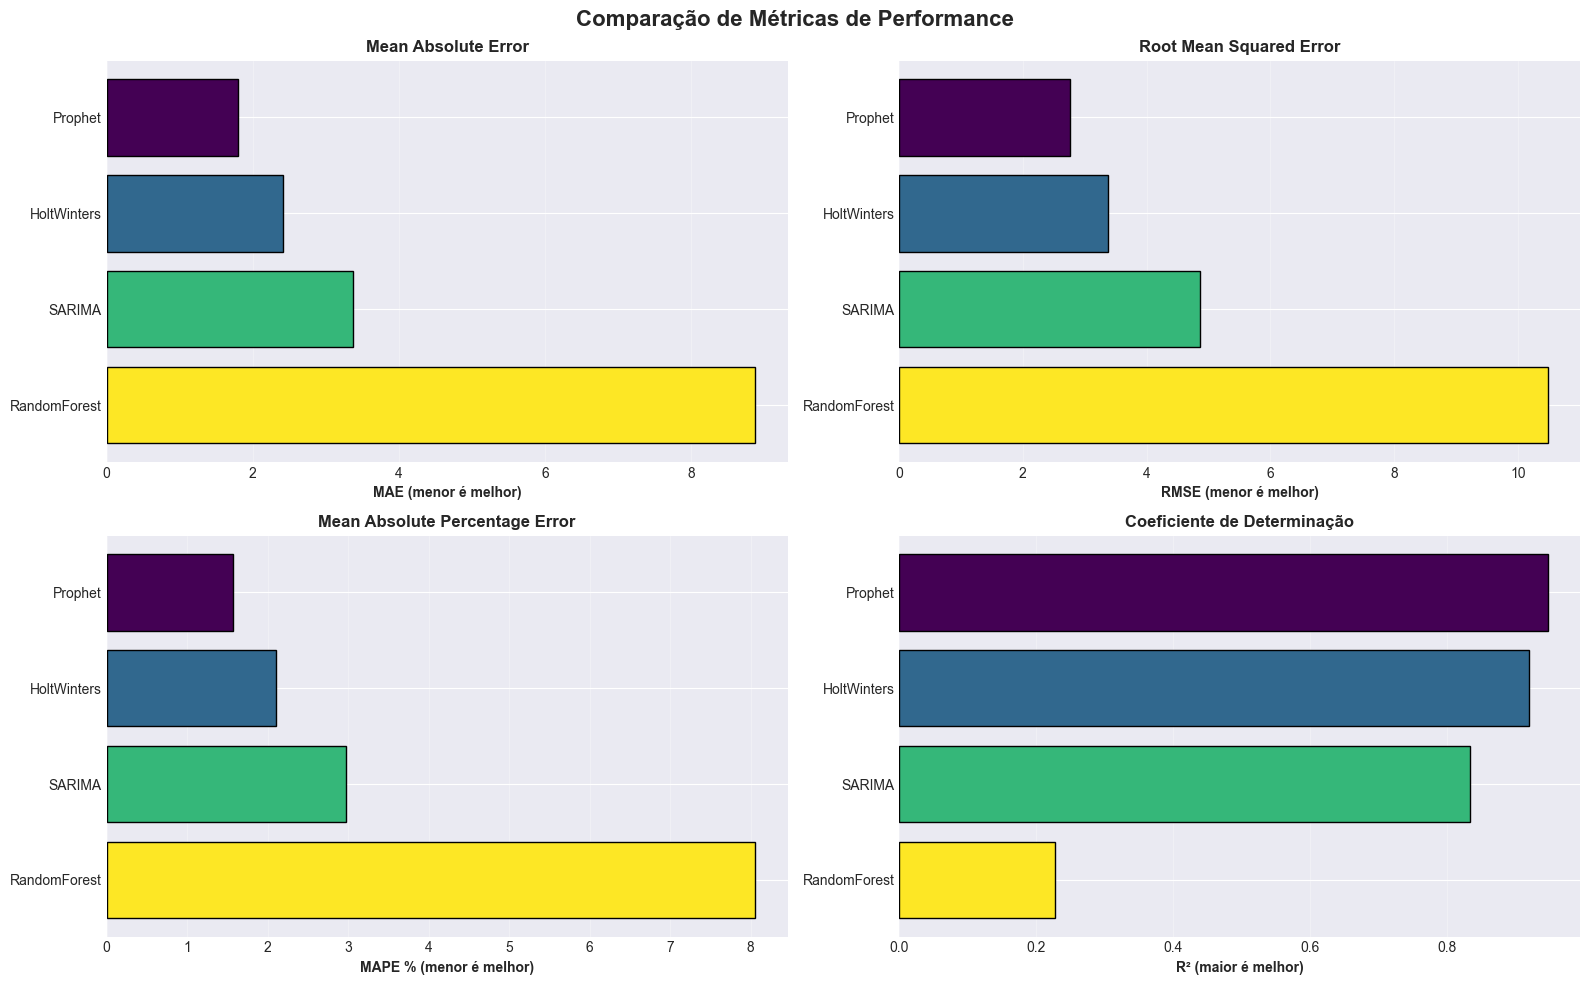


PREVISÃO FUTURA - 12 PERÍODOS À FRENTE

Gerando previsões com Random Forest...
✓ Random Forest concluído
Gerando previsões com Holt-Winters...
✓ Holt-Winters concluído
Gerando previsões com SARIMA...
✓ SARIMA concluído
Gerando previsões com Prophet...
✓ Prophet concluído


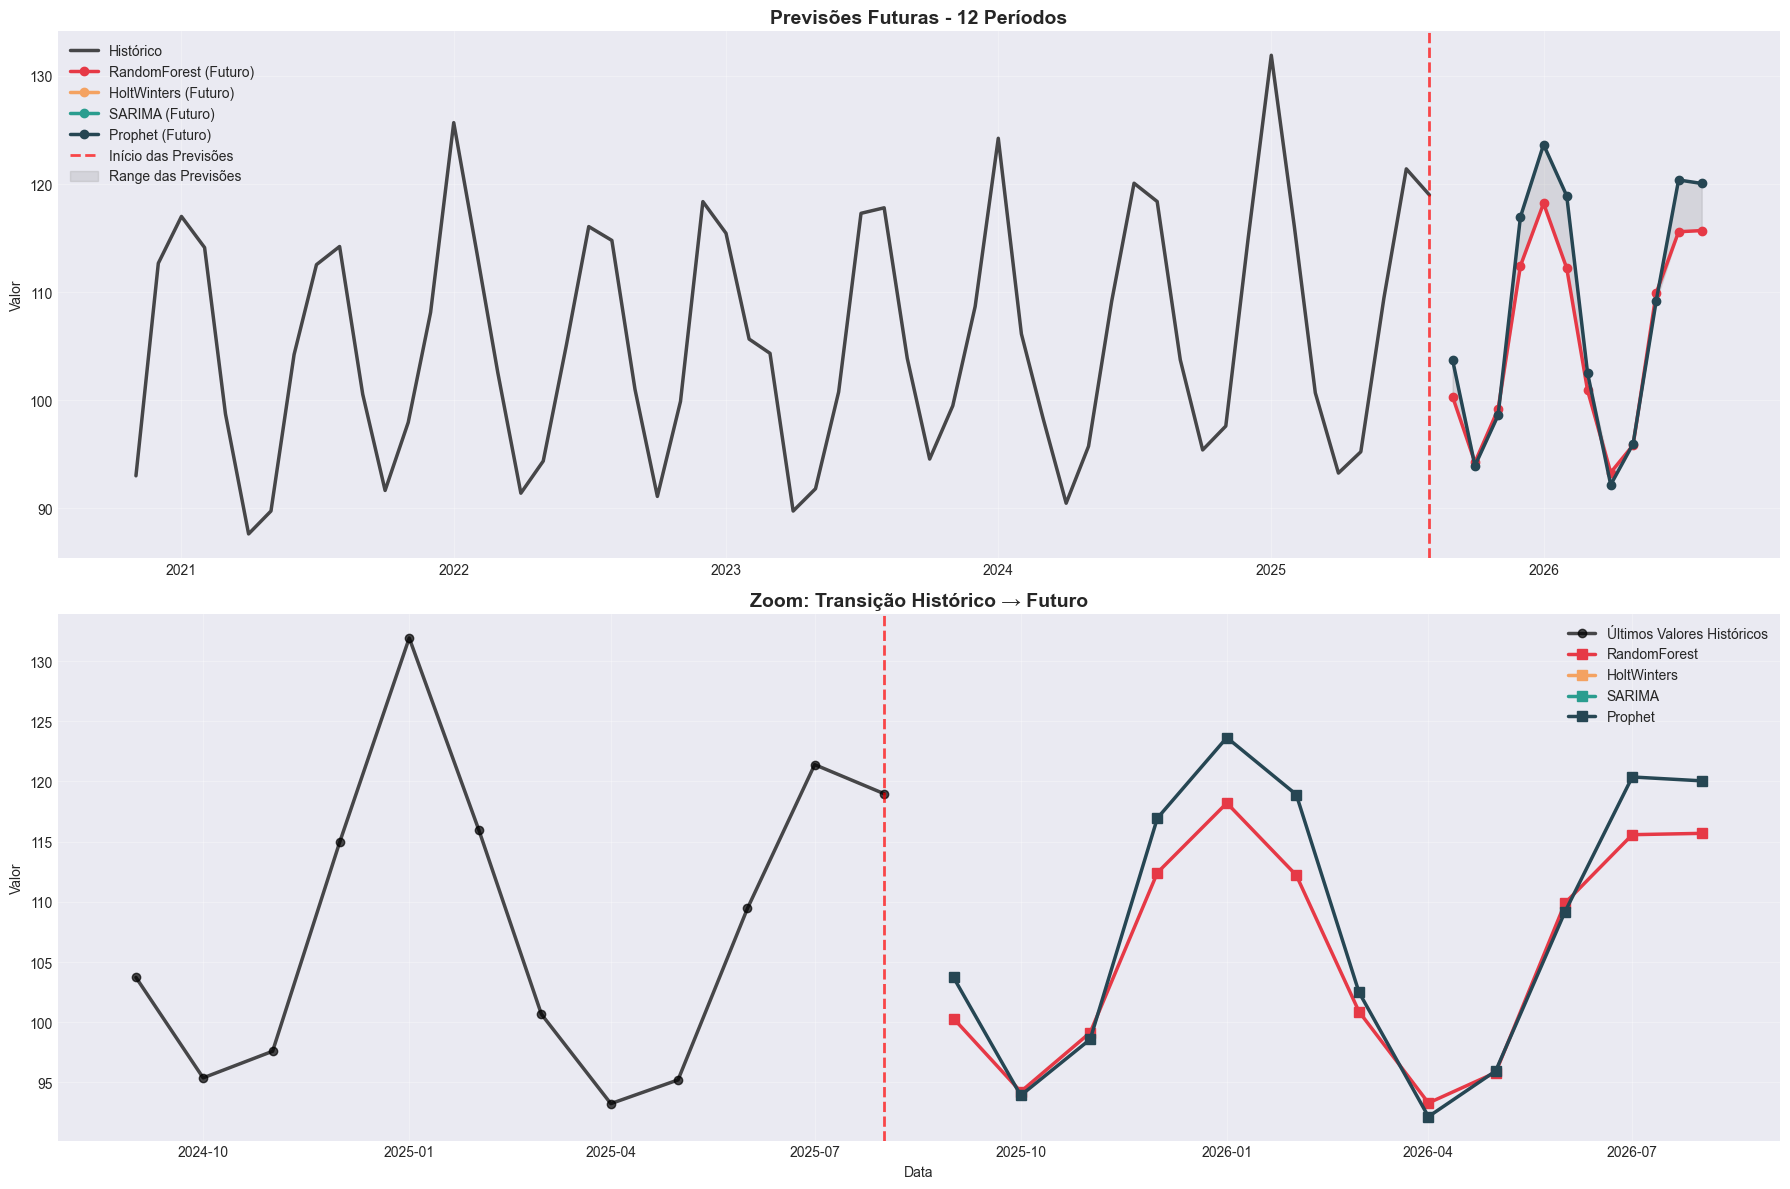


RESUMO DAS PREVISÕES FUTURAS

            RandomForest  HoltWinters  SARIMA  Prophet
2025-09-01        100.31          NaN     NaN   103.72
2025-10-01         94.24          NaN     NaN    93.92
2025-11-01         99.15          NaN     NaN    98.59
2025-12-01        112.43          NaN     NaN   116.96
2026-01-01        118.21          NaN     NaN   123.65
2026-02-01        112.21          NaN     NaN   118.91
2026-03-01        100.89          NaN     NaN   102.49
2026-04-01         93.30          NaN     NaN    92.16
2026-05-01         95.82          NaN     NaN    95.95
2026-06-01        109.91          NaN     NaN   109.19
2026-07-01        115.58          NaN     NaN   120.37
2026-08-01        115.69          NaN     NaN   120.05

Estatísticas por período:
       RandomForest  HoltWinters  SARIMA  Prophet
count         12.00          0.0     0.0    12.00
mean         105.64          NaN     NaN   108.00
std            9.23          NaN     NaN    11.58
min           93.30        

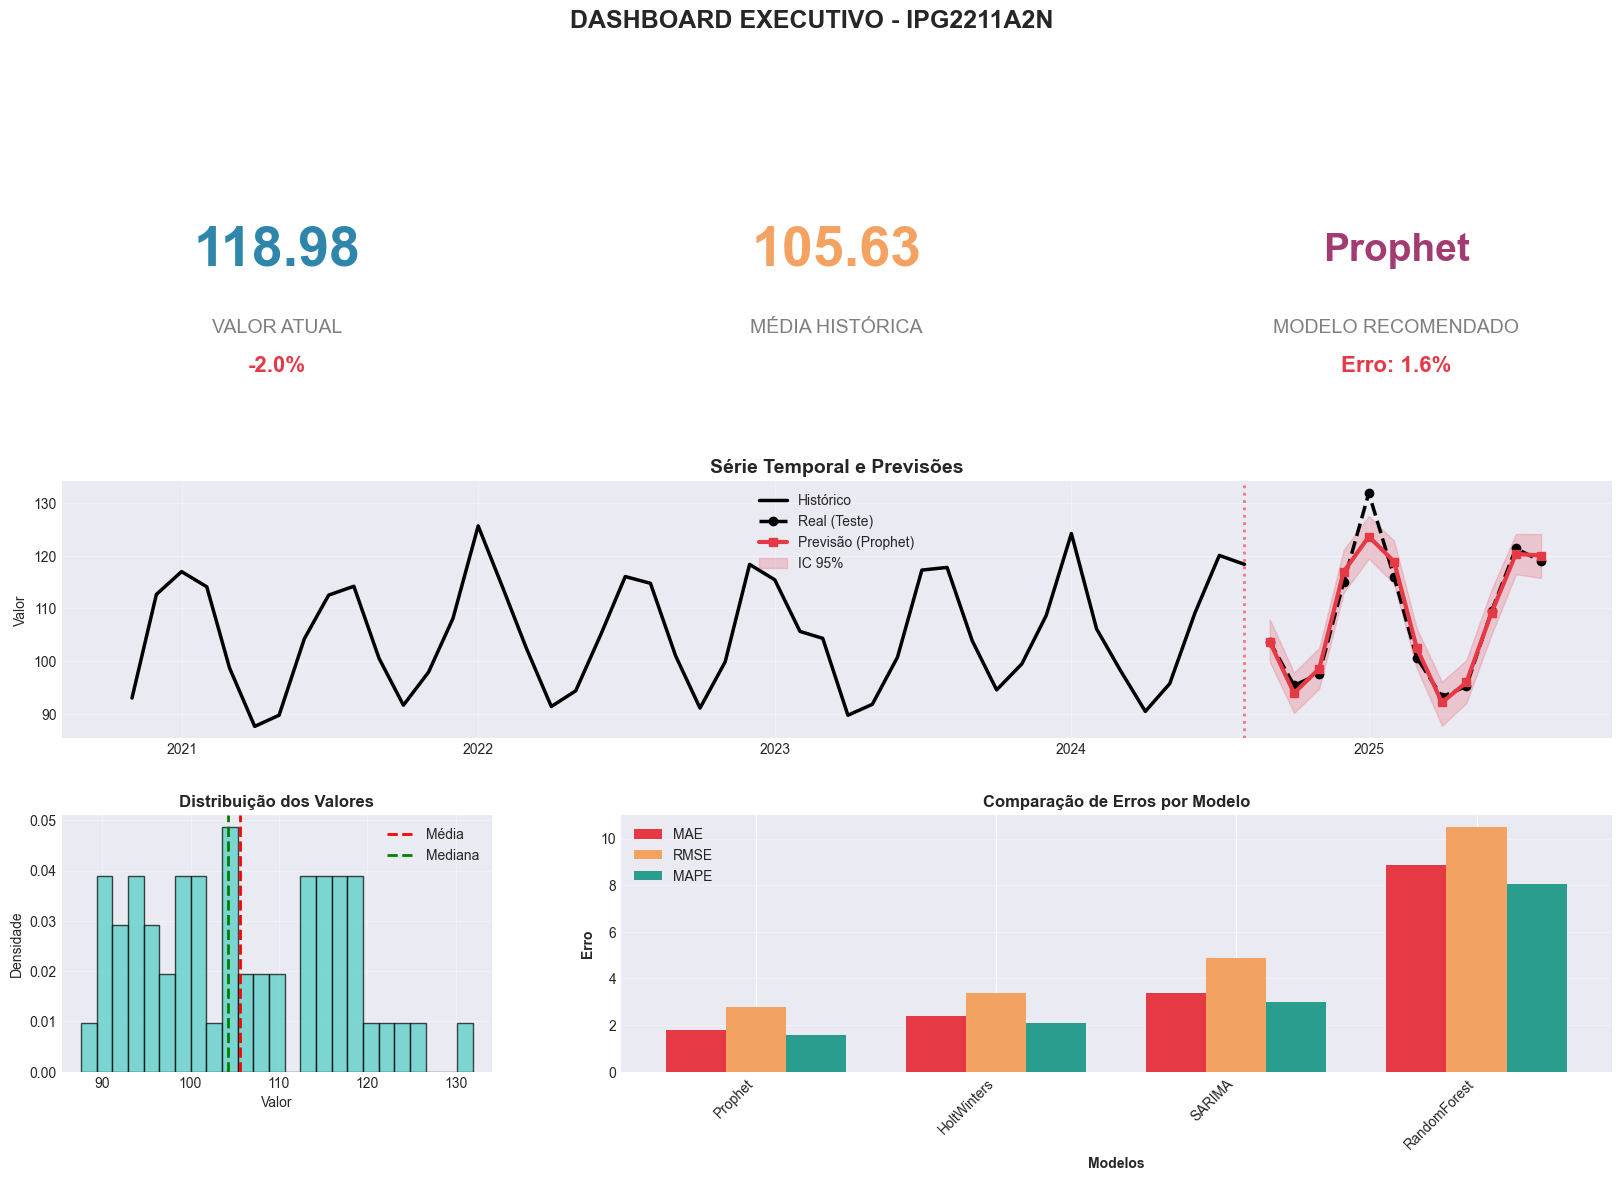


7. RELATÓRIO EXECUTIVO

RESUMO DA ANÁLISE
--------------------------------------------------------------------------------
Variável Analisada: IPG2211A2N
Período: 2020-11-01 até 2025-08-01
Total de Observações: 58
Frequência: MS

Tendência Geral: CRESCIMENTO de 28.0%
Valor Médio: 105.63
Volatilidade (CV): 10.3%

🏆 MODELO RECOMENDADO: Prophet
   Precisão: 98.4% (Erro médio: 1.6%)
   Interpretação: O modelo erra em média 1.6% do valor real

PRÓXIMA PREVISÃO: 103.72
   Intervalo de Confiança 95%: [99.93, 107.95]
   Cenário Pessimista: 99.93
   Cenário Mais Provável: 103.72
   Cenário Otimista: 107.95

ANÁLISE COMPLETA FINALIZADA



In [3]:
df = pd.read_csv('../06_Energia_INT.csv')

analisador = AnalisadorSerieTemporalCompleto(
    df=df,
    data_col='DATE',
    valor_col='IPG2211A2N',
    frequencia='MS', 
    test_size=0.2
)
previsoes = analisador.analise_completa(periodos_futuros=12)